# Import

In [1]:
import ast
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib import cm
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import xarray as xr
from shapely.geometry import mapping, shape, MultiPolygon, box, Point
from affine import Affine
import rasterio
from shapely import wkt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches  # Import for custom legend
from dotenv import load_dotenv
import os
from pathlib import Path
import json
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd
from scipy.stats import zscore
from scipy.stats import zscore
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import gaussian_filter

# Set font sizes for various components
plt.rcParams.update({
    'font.size': 16,           # Global font size
    'axes.titlesize': 24,      # Title font size
    'axes.labelsize': 24,      # X and Y label font size
    'xtick.labelsize': 16,     # X tick label font size
    'ytick.labelsize': 16,     # Y tick label font size
})

# Importing specific functions from the module
from func_preprocessing import restructure_dataset, remove_outliers, smooth
from func_indecies import ndvi, nbr, ndwi, ndre, tcw, tcg, tcb, ndmi, nirv, kndvi, drs, ndrs, kdrs, kndrs
from func_helper import parse_custom_colors, format_label

# Functions

In [2]:
def load_dissolved_refdm(refdm_path):
    """
    Load and process a GeoDataFrame from the given path. The processing includes converting
    necessary columns to numeric, dissolving geometries by ID_E and S1_YEAR, calculating 
    the duration for each ID_E, and returning the processed DataFrame.

    Parameters:
    refdm_path (str): Path to the GeoDataFrame file.

    Returns:
    GeoDataFrame: Processed GeoDataFrame with a 'Duration' column indicating the number 
                  of unique years for each ID_E.
    """
    # Load the GeoDataFrame
    refdm = gpd.read_file(refdm_path)
    

    print("CRS:", refdm.crs)
    print(f"Size of refdm_dataset: {len(refdm)}")

    # Convert columns to numeric, if not already
    refdm['SURVEY_Y'] = pd.to_numeric(refdm['SURVEY_Y'], errors='coerce')
    refdm['S1_YEAR'] = pd.to_numeric(refdm['S1_YEAR'], errors='coerce')
    
    # Dissolve geometries by ID_E and S1_YEAR
    dissolved_refdm = refdm.dissolve(by=['ID_E', 'S1_YEAR']).reset_index()
    
    # Group by ID_E and aggregate unique years
    unique_years_per_id = dissolved_refdm.groupby('ID_E')['S1_YEAR'].unique().reset_index()
    
    # Calculate the duration (number of unique years) for each ID_E
    unique_years_per_id['Duration'] = unique_years_per_id['S1_YEAR'].apply(len)
    
    # Merge the calculated duration with the main DataFrame
    dissolved_df = dissolved_refdm.merge(unique_years_per_id[['ID_E', 'Duration']], on='ID_E')
    
    # Dissolve geometries again by ID_E to ensure aggregation and reset index
    dissolved_df = dissolved_df.dissolve(by=['ID_E']).reset_index()
    print(f"Size of unique refdm_dataset events: {len(dissolved_df)}")
    return dissolved_df


def load_ids_dataset(path):
    gdf_ids = gpd.read_file(path)
    print("CRS:", gdf_ids.crs)
    print(f"Size of gdf_ids: {len(gdf_ids)}")
    return gdf_ids


def add_minicube_index(intersected_grid, ids):

    # Function to get intersecting indices
    def get_intersecting_indices(geometry, grid):
        intersecting_indices = grid[grid.intersects(geometry)].index.tolist()
        return intersecting_indices

    # Apply the function to each row in reprojected_refdm
    ids['minicube_index'] = ids['geometry'].apply(lambda geom: get_intersecting_indices(geom, intersected_grid))

    # Add the 'cube_amount' column by counting the length of each list in 'minicube_index'
    ids['cube_amount'] = ids['minicube_index'].apply(len)

    return ids

In [3]:
def extract_unique_minicubes(refdm_filtered, ids_filtered, intersected_grid):
    def convert_to_list(value):
        """Convert string representation of list to an actual list or return value directly."""
        try:
            return ast.literal_eval(value) if isinstance(value, str) else value
        except (ValueError, SyntaxError):
            return []

    # Extract and flatten minicube values for refdm
    minicube_refdm = [
        int(item)
        for sublist in [convert_to_list(val) for val in refdm_filtered['mini_idx'].values]
        for item in sublist
    ]

    # print(f"REFDM: {minicube_refdm}")
    
    # Extract and flatten minicube values for ids
    minicube_ids = [
        int(item)
        for sublist in [convert_to_list(val) for val in ids_filtered['mini_idx'].values]
        for item in sublist
    ]
    # print(f"IDS: {minicube_ids}")

    # Combine both lists and get unique values
    unique_minicubes = list(set(minicube_refdm + minicube_ids))

    # Use .isin() to filter when unique_minicubes is a list
    grid = intersected_grid.loc[intersected_grid['FID'].isin(unique_minicubes)]

    return unique_minicubes, grid


In [4]:
def calculatePerfectSaison(mc, start_year, method='mean'):
    """
    Calculate a perfect seasonal time series and compare it with the original time series.

    Parameters:
        mc (xarray.Dataset): The original time series dataset.
        start_year (int): The starting year for the seasonal calculation.
        method (str): Method for calculating seasonal values ('mean', 'max', or 'min').

    Returns:
        difference (xarray.Dataset): The difference between the perfect seasonal and original time series.
        perfect_seasonal (xarray.Dataset): The perfect seasonal time series.
        normal_timeseries (xarray.Dataset): The original time series after smoothing.
    """
    
    # General start of calculation
    print(f"Starting the calculation of {method} season...")

    # Define constants
    num_years = 8
    num_weeks_per_year = 52
    min_year = 2016  # We only calculate mean/min/max from 2017 onwards
    
    # Custom preprocessing to resample the original dataset to weekly frequency
    mc_reprocessed = mc.resample(time="1W").mean()

    # Filter the dataset for time after 2016 for aggregation
    mc_filtered = mc_reprocessed.sel(time=mc_reprocessed['time'].dt.year >= min_year)

    # Calculate the mean, max, or min values for each week of the year from 2017 onwards
    if method == 'mean':
        ds_weekly_agg = mc_filtered.groupby(mc_filtered['time'].dt.isocalendar().week).mean(dim='time')
    elif method == 'max':
        ds_weekly_agg = mc_filtered.groupby(mc_filtered['time'].dt.isocalendar().week).max(dim='time')
    elif method == 'min':
        ds_weekly_agg = mc_filtered.groupby(mc_filtered['time'].dt.isocalendar().week).min(dim='time')
    else:
        raise ValueError("Invalid method. Use 'mean', 'max', or 'min'.")

    # Create an empty list to store datasets for each year
    yearly_datasets = []

    # Iterate over all years in the original dataset (not just after 2016)
    for year in range(start_year, mc_reprocessed['time'].dt.year.max().item() + 1):
        # Generate a list of datetime objects with weekly frequency for each year
        date_range = pd.date_range(start=f"{year}-01-01", periods=num_weeks_per_year, freq='W')

        # Repeat the mean/max/min values for each week
        weekly_values_repeated = ds_weekly_agg.isel(week=slice(0, num_weeks_per_year)).rename({'week': 'time'})

        # Create a new dataset with the desired time values
        new_time_dataset = xr.Dataset(
            data_vars={
                'time': ('time', date_range)
            }
        )

        # Convert the 'time' data of weekly_values_repeated to match the data type of new_time_dataset
        weekly_values_repeated['time'] = new_time_dataset['time']

        # Use combine_first to concatenate the new dataset with weekly_values_repeated while ignoring NaN values
        yearly_dataset = weekly_values_repeated.combine_first(new_time_dataset)

        # Append the yearly dataset to the list
        yearly_datasets.append(yearly_dataset)

    # Concatenate all the yearly datasets along the 'time' dimension with NaN values ignored
    perfect_seasonal = xr.concat(yearly_datasets, dim='time')

    # Calculate the difference between the perfect seasonal and the original time series (over the whole timespan)
    difference = mc_reprocessed - perfect_seasonal
    
    print("Calculation completed.")

    return difference, perfect_seasonal, mc_reprocessed


# Code

In [5]:
# Load environment variables from the .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)

# Retrieve environment variables
grid_folder = os.getenv('EQUI7_GRIDS')
print(f"Equi7 grids folder: {grid_folder}")

# Check if the folder exists
if not os.path.isdir(grid_folder):
    raise FileNotFoundError(f"The folder {grid_folder} does not exist.")

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)

# Parameters for the grid
resolution = 10
pixel_size = 512


ids_equi7_path = f"{os.getenv('RESULTS')}/region{region_id}_dca_filtered_ids_usda_polygons_espg_27705.shp"
refdm_equi7_path = f"{os.getenv('RESULTS')}s1dm.shp"  # radar_results/radar_enhanced_forest_disturbance_mapping_region_{region_id}_epsg_27705.shp"
path_grid = f"{grid_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}.shp"
path_conves = f"{os.getenv('RESULTS')}/radar_results/convex_hulls_refdm_region_{region_id}_epsg_4326.shp"
path_intersetion_grid = f"{grid_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}_intersetion.shp"


figure_output_path = f"{os.getenv('FIGURES')}"
if not os.path.exists(figure_output_path):
        os.makedirs(figure_output_path)
        

s2_minicube_folder = os.getenv('SENTINEL2_CUBES_PP')
print(f"Sentinel 2 NetCDF folder: {s2_minicube_folder}")

Equi7 grids folder: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids/
Sentinel 2 NetCDF folder: /net/projects/forexd/WP1/Data/S2_Minicubes_IDS_R8_Preprocessed/


In [6]:
print("Load the Forest Disturbances ...")
print("Intersected Grid ...")
intersected_grid = gpd.read_file(path_intersetion_grid)
print("Adding Minicube index to ids ...")
ids_gdf = load_ids_dataset(ids_equi7_path)
ids_mincubes = add_minicube_index(intersected_grid, ids_gdf)
print("Load Refdm ...")
s1dm = load_dissolved_refdm(refdm_equi7_path)
data = s1dm.copy()

s1dm = s1dm.rename(columns={'minicube_i': 'mini_idx'})
ids_mincubes = ids_mincubes.rename(columns={'minicube_index': 'mini_idx'})

Load the Forest Disturbances ...
Intersected Grid ...
Adding Minicube index to ids ...
CRS: EPSG:27705
Size of gdf_ids: 2491
Load Refdm ...
CRS: EPSG:4326
Size of refdm_dataset: 6046
Size of unique refdm_dataset events: 1969


In [99]:
filtered_events = ids_mincubes[ids_mincubes['mini_idx'].apply(lambda x: 722 in x)] 

# Display the filtered events
filtered_events

,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_E,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,IDX_D,geometry,mini_idx,cube_amount
1592,wind,2019,8,16,26008,None,NaN,None,NaN,3.600158,wind_2019_1592,"POLYGON ((9457115.196 2733205.261, 9457113.016...","[722, 727, 737]",3


In [7]:
dca ='wind'
filtered_df = data[data['DCA_ID'] == dca]
filtered_df = filtered_df[filtered_df['SURVEY_Y'] != 2016]
filtered_df = filtered_df[filtered_df['S1_YEAR'] != 2016]
print(len(filtered_df))
filtered_df = filtered_df.reset_index()
event = filtered_df.loc[22]
id_e = event.ID_E
print(id_e)
filtered_df

366
25900


,index,ID_E,geometry,S1_YEAR,IDX_D,S1_TILE,S1CD_IDX,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,Duration
0,1327,25744,"MULTIPOLYGON (((-85.20551 31.01256, -85.20532 ...",2017,wind_2018_2217,E093N024T3,2217,wind,2018,8,16,25912,2019.0,wind,1.0,0.000393,4
1,1457,25878,"MULTIPOLYGON (((-85.20114 31.00325, -85.20114 ...",2017,wind_2019_2311,E093N024T3,2311,wind,2019,8,16,25700,2018.0,wind,-1.0,0.001179,5
2,1458,25879,"MULTIPOLYGON (((-85.19258 31.04279, -85.19258 ...",2017,wind_2019_2312,E093N024T3,2312,wind,2019,8,16,25701,2018.0,wind,-1.0,0.002357,5
3,1459,25880,"MULTIPOLYGON (((-85.04715 31.03139, -85.04753 ...",2017,wind_2019_2313,E093N024T3,2313,wind,2019,8,16,25703,2018.0,wind,-1.0,0.014143,5
4,1460,25881,"MULTIPOLYGON (((-85.17262 31.01618, -85.17281 ...",2017,wind_2019_2314,E093N024T3,2314,wind,2019,8,16,25705,2018.0,wind,-1.0,0.005501,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,1960,26825,"MULTIPOLYGON (((-92.55981 31.70806, -92.55981 ...",2020,wind_2020_2045,E087N024T3,2045,wind,2020,8,16,None,NaN,None,NaN,1.570551,1
362,1961,26826,"MULTIPOLYGON (((-92.88621 31.71497, -92.88621 ...",2018,wind_2020_2046,E087N024T3,2046,wind,2020,8,16,None,NaN,None,NaN,0.271562,4
363,1962,26827,"MULTIPOLYGON (((-92.37444 31.68542, -92.37444 ...",2018,wind_2020_2047,E087N024T3,2047,wind,2020,8,16,None,NaN,None,NaN,0.092941,3
364,1963,26829,"MULTIPOLYGON (((-93.66029 30.3398, -93.66048 3...",2018,wind_2020_2048,E084N024T3,2048,wind,2020,8,16,None,NaN,None,NaN,0.044157,4


# Testing

In [8]:
def calculatePerfectSaison(mc, start_year,min_year, method='mean'):
    """
    Calculate a perfect seasonal time series and compare it with the original time series.

    Parameters:
        mc (xarray.Dataset): The original time series dataset.
        start_year (int): The starting year for the seasonal calculation.
        method (str): Method for calculating seasonal values ('mean', 'max', or 'min').

    Returns:
        difference (xarray.Dataset): The difference between the perfect seasonal and original time series.
        perfect_seasonal (xarray.Dataset): The perfect seasonal time series.
        normal_timeseries (xarray.Dataset): The original time series after smoothing.
    """
    
    # General start of calculation
    print(f"Starting the calculation of {method} season...")

    # Define constants
    num_years = 8
    num_weeks_per_year = 52

    # Calculate the mean, max, or min values for each week of the year from 2017 onwards
    if method == 'mean':
        mc_reprocessed = mc.resample(time="1W").mean()
        # Filter the dataset for time after 2016 for aggregation
        mc_filtered = mc_reprocessed.sel(time=mc_reprocessed['time'].dt.year >= min_year)
        ds_weekly_agg = mc_filtered.groupby(mc_filtered['time'].dt.isocalendar().week).mean(dim='time')
    elif method == 'max':
        mc_reprocessed = mc.resample(time="1W").max()
        # Filter the dataset for time after 2016 for aggregation
        mc_filtered = mc_reprocessed.sel(time=mc_reprocessed['time'].dt.year >= min_year)
        ds_weekly_agg = mc_filtered.groupby(mc_filtered['time'].dt.isocalendar().week).max(dim='time')
    elif method == 'min':
        mc_reprocessed = mc.resample(time="1W").min()
        # Filter the dataset for time after 2016 for aggregation
        mc_filtered = mc_reprocessed.sel(time=mc_reprocessed['time'].dt.year >= min_year)
        ds_weekly_agg = mc_filtered.groupby(mc_filtered['time'].dt.isocalendar().week).min(dim='time')

    else:
        raise ValueError("Invalid method. Use 'mean', 'max', or 'min'.")

   
    # Create an empty list to store datasets for each year
    yearly_datasets = []

    # Iterate over all years in the original dataset (not just after 2017)
    for year in range(start_year, mc_reprocessed['time'].dt.year.max().item() + 1):
        # Generate a list of datetime objects with weekly frequency for each year
        date_range = pd.date_range(start=f"{year}-01-01", periods=num_weeks_per_year, freq='W')

        # Repeat the mean/max/min values for each week
        weekly_values_repeated = ds_weekly_agg.isel(week=slice(0, num_weeks_per_year)).rename({'week': 'time'})

        # Create a new dataset with the desired time values
        new_time_dataset = xr.Dataset(
            data_vars={
                'time': ('time', date_range)
            }
        )

        # Convert the 'time' data of weekly_values_repeated to match the data type of new_time_dataset
        weekly_values_repeated['time'] = new_time_dataset['time']

        # Use combine_first to concatenate the new dataset with weekly_values_repeated while ignoring NaN values
        yearly_dataset = weekly_values_repeated.combine_first(new_time_dataset)

        # Append the yearly dataset to the list
        yearly_datasets.append(yearly_dataset)

    # Concatenate all the yearly datasets along the 'time' dimension with NaN values ignored
    perfect_seasonal = xr.concat(yearly_datasets, dim='time')

    # Calculate the difference only for data after min_year
    mc_reprocessed_filtered = mc_reprocessed.sel(time=mc_reprocessed['time'].dt.year >= min_year)
    difference = mc_reprocessed_filtered - perfect_seasonal

    
    print("Calculation completed.")

    return difference, perfect_seasonal, mc_reprocessed


In [9]:
def add_timestamp(series, time):
    # Generate actual timestamps from the 'day_of_year' coordinate
    # Assuming the first day of the year is 1st January of the given year
    start_date = pd.to_datetime(f"{time.year[0]}-01-01")

    # Create a timestamp for each 'day_of_year'
    timestamps = [start_date + pd.Timedelta(days=int(doy) - 1) for doy in series['doy'].values]

    # Update the 'time' coordinate with these timestamps
    series.coords['doy'] = ('doy', timestamps)
    # Step 1: Rename 'time_of_year' to 'time'
    series = series.rename({'doy': 'time'})

    return series

In [10]:
def plot_statistics_new(
    original, smoothed, difference, x_idx=None, y_idx=None, 
    variable='ndvi', statistic='max', start_year=None, end_year=None
):
    """
    Plot the original, smoothed, and difference NDVI statistics for a specific pixel and variable.

    Parameters:
        original (xarray.DataArray): The original NDVI time series resampled weekly.
        smoothed (xarray.DataArray): The smoothed NDVI statistic time series.
        difference (xarray.DataArray): The difference between the original and smoothed NDVI.
        x_idx (int, optional): The x-coordinate index of the pixel. Defaults to None.
        y_idx (int, optional): The y-coordinate index of the pixel. Defaults to None.
        variable (str): The variable name to plot (default is 'ndvi').
        statistic (str): The statistic type ('mean', 'max', or 'min') for labeling the plot.
        start_year (int, optional): The start year of the dataset (optional, for labeling).
        end_year (int, optional): The end year of the dataset (optional, for labeling).

    Returns:
        None
    """
    import matplotlib.pyplot as plt

    # Subset by x_idx and y_idx if they are provided
    if x_idx is not None and y_idx is not None:
        original = original.isel(x=x_idx, y=y_idx)
        smoothed = smoothed.isel(x=x_idx, y=y_idx)
        difference = difference.isel(x=x_idx, y=y_idx)

    # Create the plot
    plt.figure(figsize=(10, 6))

    # Plot the original, smoothed, and difference data
    plt.plot(original['time'], original[variable], label=f"Original {variable.upper()}", color='green')
    plt.plot(smoothed['time'], smoothed[variable], label=f"Smoothed Weekly {statistic.capitalize()} {variable.upper()}", linestyle='--', color='orange')
    plt.plot(difference['time'], difference[variable], label=f"Difference {statistic.capitalize()} {variable.upper()}", linestyle='-', color='blue')

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='red', linestyle='-', linewidth=1, label='y = 0')

    # Adding labels and title
    plt.xlabel('Date')
    plt.ylabel(variable.upper())
    title = f"Extended {statistic.capitalize()} {variable.upper()} Season"
    if start_year and end_year:
        title += f" for {start_year}-{end_year}"
    plt.title(title)

    # Show grid and make the plot tighter
    plt.grid(True)
    plt.tight_layout()
    #plt.legend()
    plt.show()


In [11]:
def plot_statistics(original, smoothed, difference, x_idx, y_idx, variable='ndvi', statistic='max', start_year=None, end_year=None):
    """
    Plot the original, smoothed, and difference NDVI statistics for a specific pixel and variable.

    Parameters:
        original (xarray.DataArray): The original NDVI time series resampled weekly.
        smoothed (xarray.DataArray): The smoothed NDVI statistic time series.
        difference (xarray.DataArray): The difference between the original and smoothed NDVI.
        x_idx (int): The x-coordinate index of the pixel.
        y_idx (int): The y-coordinate index of the pixel.
        variable (str): The variable name to plot (default is 'ndvi').
        statistic (str): The statistic type ('mean', 'max', or 'min') for labeling the plot.
        start_year (int): The start year of the dataset (optional, for labeling).
        end_year (int): The end year of the dataset (optional, for labeling).

    Returns:
        None
    """
    import matplotlib.pyplot as plt

    # Create the plot
    plt.figure(figsize=(10, 6))
    original = original.isel(x=x_idx, y=y_idx)
    smoothed = smoothed.isel(x=x_idx, y=y_idx)
    difference = difference.isel(x=x_idx, y=y_idx)

    
    # Plot the original, smoothed, and difference data
    plt.plot(original['time'], original[variable], label=f"Original {variable.upper()}", color='green')
    plt.plot(smoothed['time'], smoothed[variable], label=f"Smoothed Weekly {statistic.capitalize()} {variable.upper()}", linestyle='--', color='orange')
    plt.plot(difference['time'], difference[variable], label=f"Difference {statistic.capitalize()} {variable.upper()}", linestyle='-', color='blue')
    
    # Add a horizontal line at y=0
    plt.axhline(y=0, color='red', linestyle='-', linewidth=1, label='y = 0')
    
    # Adding labels and title
    plt.xlabel('Date')
    plt.ylabel(variable.upper())
    title = f"Extended {statistic.capitalize()} {variable.upper()} Season"
    if start_year and end_year:
        title += f" for {start_year}-{end_year}"
    plt.title(title)
    
    # Show grid and make the plot tighter
    plt.grid(True)
    plt.tight_layout()
    #plt.legend()
    plt.show()


25900


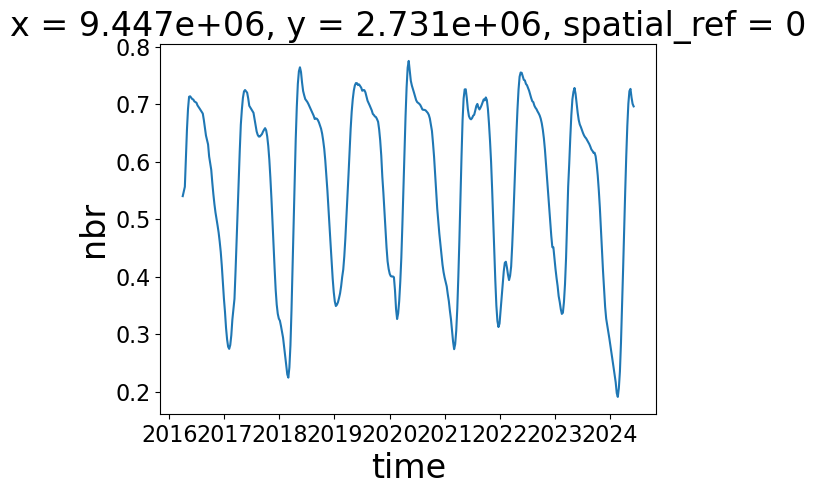

In [12]:
event = filtered_df.loc[22]
id_e = event.ID_E
print(id_e)
file_path = f"{s2_minicube_folder}/722_10_512_20152024_equi7_NA.nc"

dataset = xr.open_dataset(file_path).sortby(['y', 'x'])  # Sort by 'x' and 'y'
if not dataset.rio.crs:
    dataset = dataset.rio.write_crs(equi7_crs)

test_pixel = dataset.isel(x=20,y=200)
test_pixel['nbr'].plot()

In [ ]:
import pandas as pd

# # Extract the pixel (x=2, y=2) from the dataset
# pixel_data = dataset.isel(x=2, y=2).to_dataframe()
# Reset index for easier handling and save to CSV
# csv_path = "/net/projects/forexd/WP1/Data/pixel_2_2_data.csv"
# pixel_data.reset_index().to_csv(csv_path, index=False)

# pixel_data


,x,y,B06,B03,kndrs,B8A,vh,tcb,B11,ndwi,...,ndre,B08,B05,B09,tcw,ndmi,B01,kdrs,ndrs,spatial_ref
time,,,,,,,,,,,,,,,,,,,,,
2015-03-19,9446420.0,2728990.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2015-03-26,9446420.0,2728990.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2015-09-03,9446420.0,2728990.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2015-10-01,9446420.0,2728990.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2015-10-22,9446420.0,2728990.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04,9446420.0,2728990.0,NaN,NaN,NaN,NaN,0.048331,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2024-07-11,9446420.0,2728990.0,NaN,NaN,NaN,NaN,0.052332,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2024-07-18,9446420.0,2728990.0,NaN,NaN,NaN,NaN,0.056476,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [13]:
import pandas as pd

# Path to the CSV file
csv_path = "/net/projects/forexd/WP1/Data/pixel_2_2_data.csv"

# Load the CSV into a DataFrame
pixel_data = pd.read_csv(csv_path)

# Preview the data
print(pixel_data.head())


         time          x          y  B06  B03  kndrs  B8A  vh  tcb  B11  ...  \
0  2015-03-19  9446420.0  2728990.0  NaN  NaN    NaN  NaN NaN  NaN  NaN  ...   
1  2015-03-26  9446420.0  2728990.0  NaN  NaN    NaN  NaN NaN  NaN  NaN  ...   
2  2015-09-03  9446420.0  2728990.0  NaN  NaN    NaN  NaN NaN  NaN  NaN  ...   
3  2015-10-01  9446420.0  2728990.0  NaN  NaN    NaN  NaN NaN  NaN  NaN  ...   
4  2015-10-22  9446420.0  2728990.0  NaN  NaN    NaN  NaN NaN  NaN  NaN  ...   

   ndre  B08  B05  B09  tcw  ndmi  B01  kdrs  ndrs  spatial_ref  
0   NaN  NaN  NaN  NaN  NaN   NaN  NaN   NaN   NaN            0  
1   NaN  NaN  NaN  NaN  NaN   NaN  NaN   NaN   NaN            0  
2   NaN  NaN  NaN  NaN  NaN   NaN  NaN   NaN   NaN            0  
3   NaN  NaN  NaN  NaN  NaN   NaN  NaN   NaN   NaN            0  
4   NaN  NaN  NaN  NaN  NaN   NaN  NaN   NaN   NaN            0  

[5 rows x 32 columns]


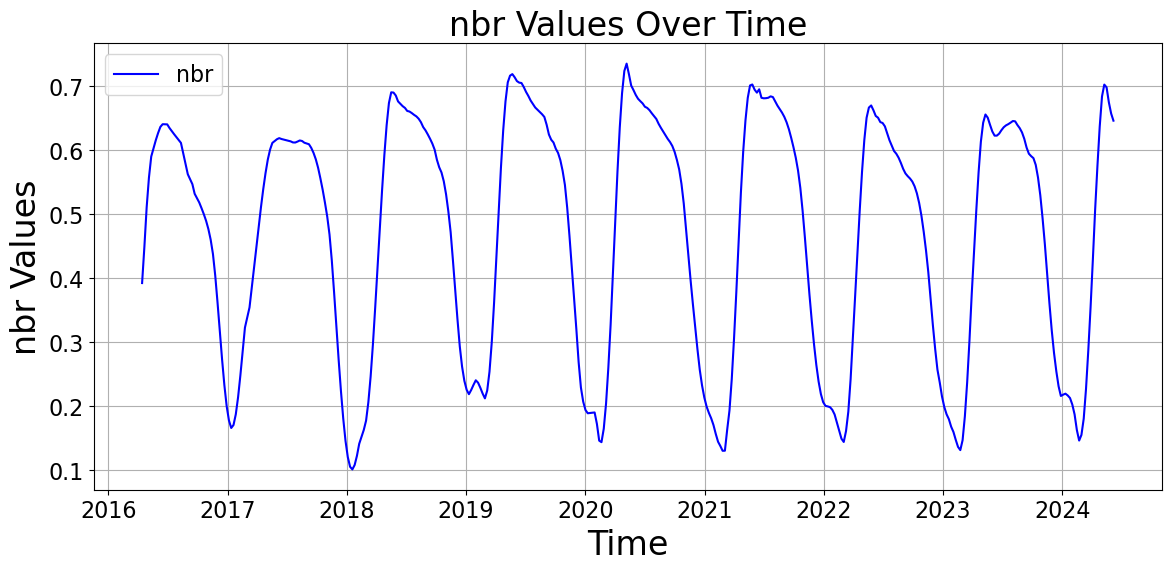

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


# Convert 'time' column to a datetime format for proper plotting
pixel_data['time'] = pd.to_datetime(pixel_data['time'])

# Plot the 'B03' values over time
plt.figure(figsize=(12, 6))
plt.plot(pixel_data['time'], pixel_data['nbr'], label='nbr', color='blue')

# Add labels, title, and legend
plt.xlabel('Time')
plt.ylabel('nbr Values')
plt.title('nbr Values Over Time')
plt.legend()

# Show grid and the plot
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2967395/2937386510.py:19: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/tmp/ipykernel_2967395/2937386510.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


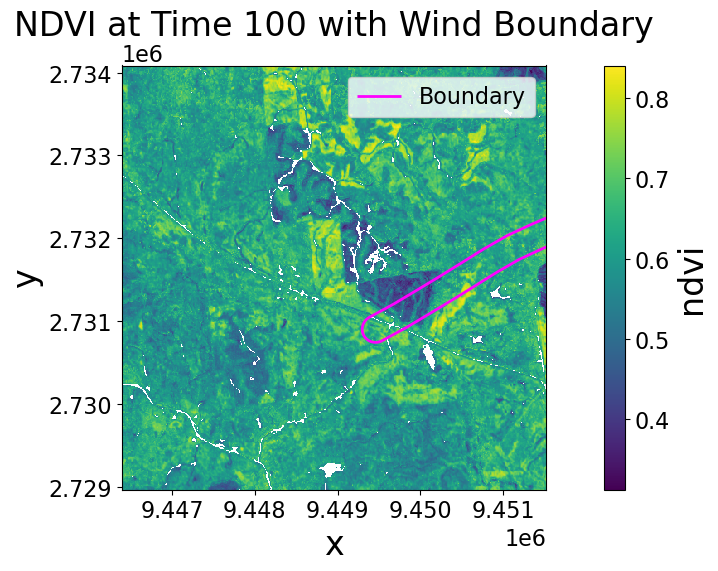

In [106]:
import matplotlib.pyplot as plt

# Assuming 'dataset' is your xarray Dataset and 'filtered_events.boundary' is a GeoDataFrame or similar
# Plot the 'ndvi' data for the specific time index (e.g., time=100)
plt.figure(figsize=(12, 6))

# Plot the 'ndvi' time series at time=100
dataset['ndvi'].isel(time=100).plot(label='NDVI at Time 100')

# Plot the 'filtered_events.boundary' with bright pink color
filtered_events.boundary.plot(ax=plt.gca(), label='Boundary', color='magenta', linewidth=2)

# Add labels and title
plt.xlabel('x')  # Change according to your data
plt.ylabel('y')
plt.title('NDVI at Time 100 with Wind Boundary')

# Add a legend to differentiate between the plots
plt.legend()

plt.tight_layout()
plt.show()


In [133]:
import xarray as xr
import pandas as pd

# Assuming 'ds' is your original dataset with a 'time' coordinate
# First, resample to daily frequency
ds_daily = dataset.isel(x=2,y=2).resample(time="1D").interpolate("linear")  # Linear interpolation
# Step 1: Extract the day of the year (DOY) and add it as a new coordinate
ds_daily['doy'] = ds_daily['time'].dt.dayofyear

# Step 2: Set the 'doy' as the new coordinate, so it will be used for plotting and analysis
ds_daily = ds_daily.set_coords('doy')
ds_daily['dates'] = ds_daily['time']
ds_daily['time'] = ds_daily['doy']
ds_daily = ds_daily.drop_vars('doy')
ds_daily

<xarray.Dataset> Size: 822kB
Dimensions:      (time: 3424)
Coordinates:
    x            float32 4B 9.446e+06
    y            float32 4B 2.729e+06
    spatial_ref  int64 8B 0
  * time         (time) int64 27kB 78 79 80 81 82 83 ... 209 210 211 212 213 214
Data variables: (12/29)
    B06          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    B03          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    kndrs        (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    B8A          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    vh           (time) float64 27kB nan nan nan nan ... 0.06014 0.06039 0.06064
    tcb          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    ...           ...
    tcw          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    ndmi         (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    B01          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    kdrs         (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    ndrs         (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    dates        (time) datetime64[ns] 27kB 2015-03-19 2015-03-20 ... 2024-08-01

In [134]:
max_values_per_doy = ds_daily.groupby('time').mean(dim='time')
max_values_per_doy

<xarray.Dataset> Size: 85kB
Dimensions:      (time: 366)
Coordinates:
    x            float32 4B 9.446e+06
    y            float32 4B 2.729e+06
    spatial_ref  int64 8B 0
  * time         (time) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366
Data variables: (12/28)
    B06          (time) float64 3kB 1.366e+03 1.365e+03 ... 1.369e+03 1.319e+03
    B03          (time) float64 3kB 410.8 411.6 412.8 ... 408.7 409.5 371.7
    kndrs        (time) float64 3kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    B8A          (time) float64 3kB 1.942e+03 1.938e+03 ... 1.948e+03 1.912e+03
    vh           (time) float64 3kB 0.05498 0.05509 0.05521 ... 0.05493 0.0476
    tcb          (time) float64 3kB 2.667e+03 2.67e+03 ... 2.663e+03 2.518e+03
    ...           ...
    B09          (time) float64 3kB 1.997e+03 1.994e+03 ... 2.001e+03 1.935e+03
    tcw          (time) float64 3kB -1.062e+03 -1.065e+03 ... -1.039e+03
    ndmi         (time) float64 3kB -0.06748 -0.06866 ... -0.06561 -0.07346
    B01          (time) float64 3kB 228.1 228.9 230.2 ... 225.7 226.5 221.5
    kdrs         (time) float64 3kB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0 2.0
    ndrs         (time) float64 3kB 0.1403 0.1408 0.1413 ... 0.1392 0.1397 0.136

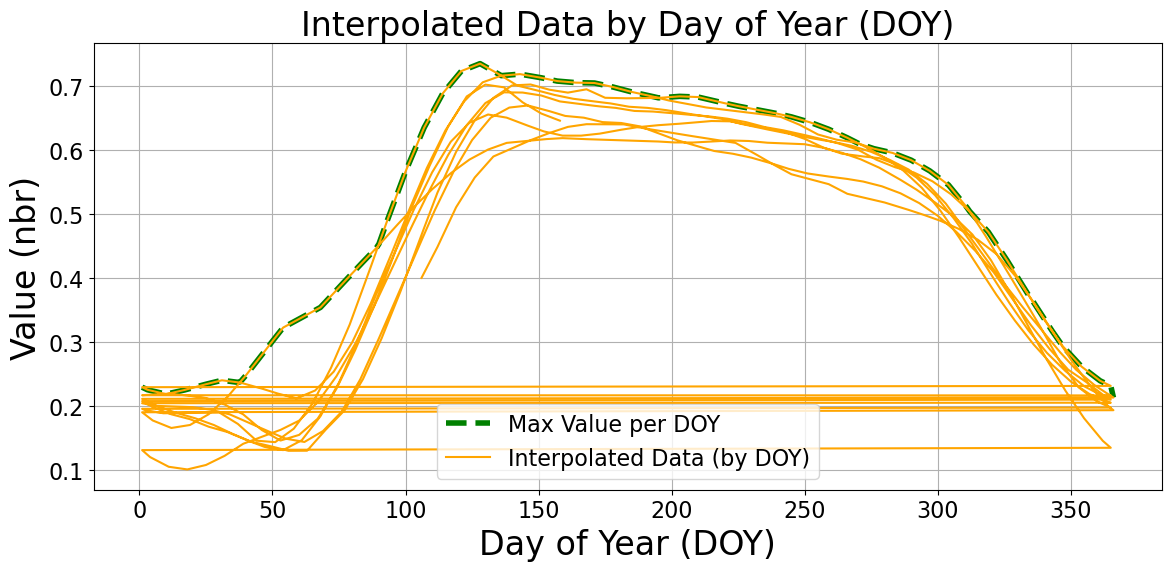

In [135]:
import xarray as xr
import matplotlib.pyplot as plt
# Assuming 'ds_daily' is your original dataset
# Step 1: Calculate the maximum value for each DOY across all years
max_values_per_doy = ds_daily.groupby('time').max(dim='time')

# Plot the max values per DOY for the 'nbr' variable
plt.figure(figsize=(12, 6))
max_values_per_doy['nbr'].plot(label="Max Value per DOY", color='green', linestyle='--', linewidth=4)
# Step 3: You can use 'doy' as the x-axis for plotting

# Plot using the 'doy' coordinate
ds_daily['nbr'].plot(label="Interpolated Data (by DOY)", color='orange', linestyle='-')


# Adding labels, title, and legend
plt.xlabel('Day of Year (DOY)')
plt.ylabel('Value (nbr)')
plt.title('Interpolated Data by Day of Year (DOY)')
plt.legend()

# Show grid and plot
plt.grid(True)
plt.tight_layout()
plt.show()


In [124]:
import pandas as pd

# Assuming you have already calculated the max_values_per_doy with 'doy' as the coordinate
# Convert 'doy' to datetime by adding the doy to the start of each year

# Create a new datetime coordinate based on the year and day of year
max_values_per_doy['date'] = pd.to_datetime(
    max_values_per_doy['time'].dt.year.astype(str) + '-01-01', format='%Y-%m-%d'
) + pd.to_timedelta(max_values_per_doy['doy'] - 1, unit='D')

# Set 'date' as the new time coordinate
max_values_per_doy = max_values_per_doy.rename({'date': 'time'})

# Now 'time' is in actual datetime values
max_values_per_doy


AttributeError: 'DataArray' object has no attribute 'dt'

In [ ]:
 # Iterate over all years in the original dataset (not just after 2017)
    for year in range(start_year, mc_reprocessed['time'].dt.year.max().item() + 1):
        # Generate a list of datetime objects with weekly frequency for each year
        date_range = pd.date_range(start=f"{year}-01-01", periods=num_weeks_per_year, freq='W')

        # Repeat the mean/max/min values for each week
        weekly_values_repeated = ds_weekly_agg.isel(week=slice(0, num_weeks_per_year)).rename({'week': 'time'})

        # Create a new dataset with the desired time values
        new_time_dataset = xr.Dataset(
            data_vars={
                'time': ('time', date_range)
            }
        )

        # Convert the 'time' data of weekly_values_repeated to match the data type of new_time_dataset
        weekly_values_repeated['time'] = new_time_dataset['time']

        # Use combine_first to concatenate the new dataset with weekly_values_repeated while ignoring NaN values
        yearly_dataset = weekly_values_repeated.combine_first(new_time_dataset)

        # Append the yearly dataset to the list
        yearly_datasets.append(yearly_dataset)

    # Concatenate all the yearly datasets along the 'time' dimension with NaN values ignored
    perfect_seasonal = xr.concat(yearly_datasets, dim='time')

    # Calculate the difference only for data after min_year
    mc_reprocessed_filtered = mc_reprocessed.sel(time=mc_reprocessed['time'].dt.year >= min_year)
    difference = mc_reprocessed_filtered - perfect_seasonal

    
    print("Calculation completed.")

    return difference, perfect_seasonal, mc_reprocessed

<xarray.Dataset> Size: 794kB
Dimensions:      (time: 3424)
Coordinates:
    x            float32 4B 9.446e+06
    y            float32 4B 2.729e+06
    spatial_ref  int64 8B 0
  * time         (time) int64 27kB 78 79 80 81 82 83 ... 209 210 211 212 213 214
Data variables: (12/28)
    B06          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    B03          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    kndrs        (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    B8A          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    vh           (time) float64 27kB nan nan nan nan ... 0.06014 0.06039 0.06064
    tcb          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    ...           ...
    B09          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    tcw          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    ndmi         (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    B01          (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    kdrs         (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan
    ndrs         (time) float64 27kB nan nan nan nan nan ... nan nan nan nan nan

In [81]:
import matplotlib.pyplot as plt
import xarray as xr

# Assuming 'dataset' is your original xarray dataset

# 1. Plot the original data for the pixel at (x=2, y=2) by the day of the year
data = dataset

# Extract the day of the year
data['day_of_year'] = data['time'].dt.dayofyear

# 2. Resample the dataset to weekly values and calculate the max for each week
mc_reprocessed = data.resample(time="1D").interpolate("linear") #.max()  # Resampling by week
mc_filtered = mc_reprocessed.sel(time=mc_reprocessed['time'].dt.year >= 2017)  # Filter after 2016
ds_weekly_agg = mc_filtered.groupby(mc_filtered['time'].dt.isocalendar().day).max(dim='time')  # Group by week and calculate max

# Select the pixel (x=2, y=2) for the resampled dataset
weekly_data = ds_weekly_agg['day_of_year'] = ds_weekly_agg['week'].dt.dayofyear

# 1. Plot the original data for the pixel at (x=2, y=2) by the day of the year
weekly_data = weekly_data['nbr'].isel(x=2, y=2)

# 3. Plot the results
plt.figure(figsize=(12, 6))

# Plot original daily data (by day of year)
plt.plot(data['day_of_year'], data.values, label='Original Daily Data', color='green', alpha=0.6)

# Plot the resampled weekly data
plt.plot(weekly_data['day_of_year'], weekly_data.values, label='Resampled Weekly Max', color='orange', linestyle='--')

# Add labels, title, and legend
plt.xlabel('Day of Year')
plt.ylabel('Value')
plt.title('Comparison of Daily and Weekly Resampled Data')
plt.legend()

# Show grid and plot
plt.grid(True)
plt.tight_layout()
plt.show()


: 

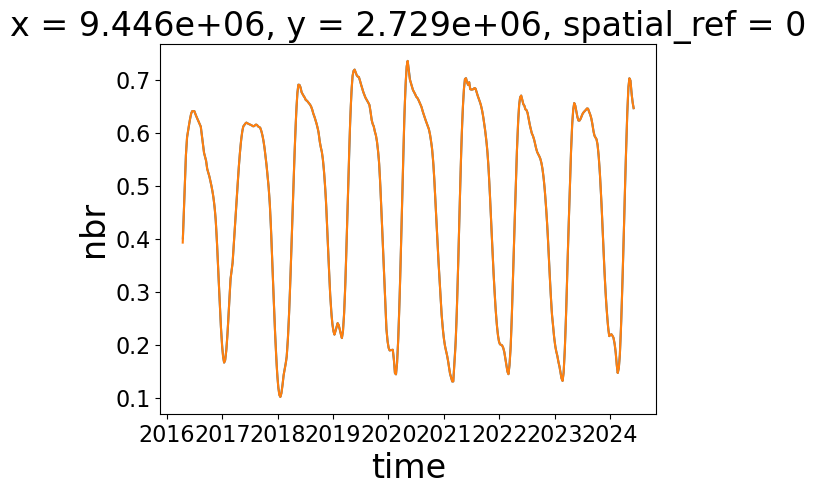

In [73]:
ds_daily['nbr'].isel(x=2,y=2).plot()
dataset['nbr'].isel(x=2,y=2).plot()

In [12]:
mc_reprocessed = dataset.resample(time="1W").max()
# Filter the dataset for time after 2016 for aggregation
mc_filtered = mc_reprocessed.sel(time=mc_reprocessed['time'].dt.year >= 2017)
ds_weekly_agg = mc_filtered.groupby(mc_filtered['time'].dt.isocalendar().week).max(dim='time')

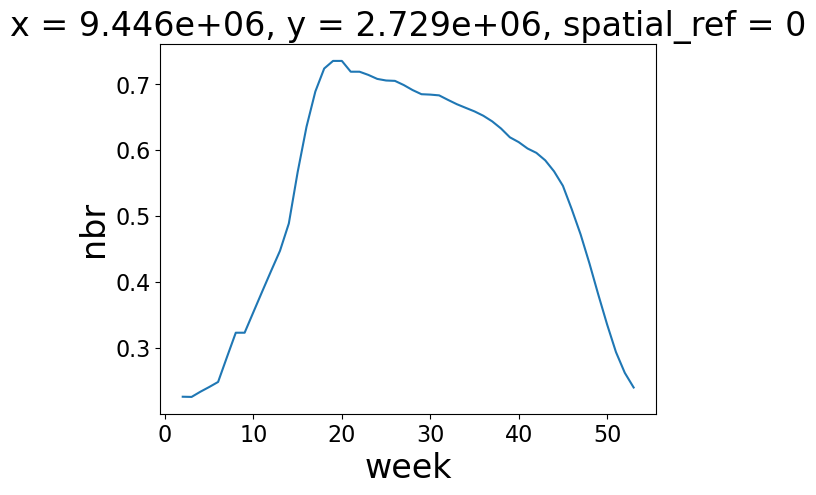

In [45]:
ds_weekly = ds_weekly_agg['nbr'].isel(x=2, y=2)
# Apply a rolling average or interpolation to smooth year transitions
perfect_seasonal = ds_weekly.rolling(week=2, center=True).max()
perfect_seasonal.plot()

In [122]:
#clipped_ids = clipped_ids.mean(dim=['x', 'y']).interpolate_na(dim='time', method='linear')
#clipped_refdm = clipped_refdm.mean(dim=['x', 'y']).interpolate_na(dim='time', method='linear')
print('Calculate diff')
difference, perfect_seasonal, mc_reprocessed = calculatePerfectSaison(dataset.isel(x=2,y=200), start_year=2016, min_year=2017, method='max')

Calculate diff
Starting the calculation of max season...
Calculation completed.


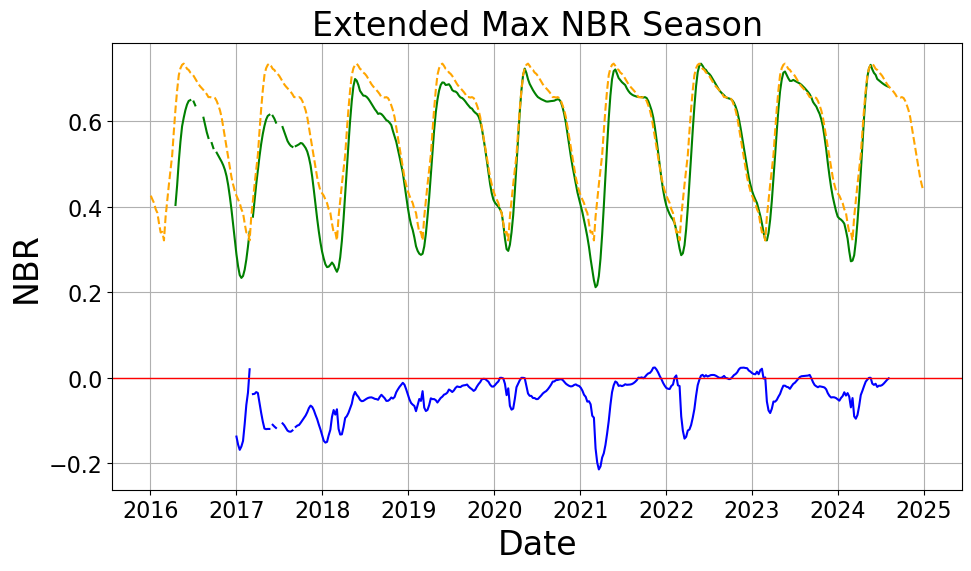

In [123]:
plot_statistics_new(mc_reprocessed, perfect_seasonal, difference, x_idx=None, y_idx=None, variable='nbr', statistic='max')

In [33]:
perfect_seasonal.isel(time=slice(50, 60))['time'].values

array(['2016-12-18T00:00:00.000000000', '2016-12-25T00:00:00.000000000',
       '2017-01-01T00:00:00.000000000', '2017-01-08T00:00:00.000000000',
       '2017-01-15T00:00:00.000000000', '2017-01-22T00:00:00.000000000',
       '2017-01-29T00:00:00.000000000', '2017-02-05T00:00:00.000000000',
       '2017-02-12T00:00:00.000000000', '2017-02-19T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [15]:
subset = dataset.isel(x=slice(10, 15), y=slice(20, 25))
subset = subset.mean(dim=['x', 'y']).interpolate_na(dim='time', method='linear')
subset

<xarray.Dataset> Size: 52kB
Dimensions:      (time: 433)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2015-03-19 2015-03-26 ... 2024-08-01
    spatial_ref  int64 8B 0
Data variables: (12/28)
    B06          (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    B03          (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    kndrs        (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    B8A          (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    vh           (time) float32 2kB 0.04169 0.04099 0.04032 ... 0.04169 0.03981
    tcb          (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    ...           ...
    B09          (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    tcw          (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    ndmi         (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    B01          (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    kdrs         (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan
    ndrs         (time) float32 2kB nan nan nan nan nan ... nan nan nan nan nan

In [39]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'dataset' is already loaded, and 'ndvi' has time, x, y coordinates.
# Step 1: Select the pixel and create the daily "Perfect Season"
ndvi_series = dataset.isel(x=2, y=2)
original_weekly = ndvi_series.resample(time='W').mean()
statistic = 'max'
# Assuming `ndvi_series` already exists
time = pd.to_datetime(original_weekly['time'].values)
start_year = time.min().year
end_year = time.max().year

# Create "Perfect Season" (mean across time grouped by day_of_year)
original_weekly.coords['doy'] = ('time', time.day_of_year)

# Calculate max, min, and mean for each day of the year
if statistic == 'mean':
    weekly_stat = original_weekly.groupby('doy').mean(dim='time')
    weekly_stat = add_timestamp(weekly_stat,time)
    weekly_stat = weekly_stat.resample(time='W').mean()
elif statistic == 'max':
    weekly_stat = original_weekly.groupby('doy').max(dim='time')
    weekly_stat = add_timestamp(weekly_stat,time)
    weekly_stat = weekly_stat.resample(time='W').max()
elif statistic == 'min':
    weekly_stat = original_weekly.groupby('doy').min(dim='time')
    weekly_stat = add_timestamp(weekly_stat,time)
    weekly_stat = weekly_stat.resample(time='W').min()

# Step 2: Define the number of weeks per year
num_weeks_per_year = len(weekly_stat['time'])

# Step 3: Create an empty list to hold the resampled statistics for each year
all_years_stat = []

# Iterate over all years in the original dataset
for year in range(start_year, end_year + 1):

    date_range = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq='W')

    # Repeat the mean/max/min values for each week
    weekly_values_repeated = weekly_stat.isel(time=slice(0, num_weeks_per_year))

    # Create a new dataset with the desired time values
    new_time_dataset = xr.Dataset(
        data_vars={
            'time': ('time', date_range)
        }
    )

    # Convert the 'time' data of weekly_values_repeated to match the data type of new_time_dataset
    weekly_values_repeated['time'] = new_time_dataset['time']

    # Use combine_first to concatenate the new dataset with weekly_values_repeated while ignoring NaN values
    yearly_dataset = weekly_values_repeated.combine_first(new_time_dataset)

    # Append the yearly dataset to the list
    all_years_stat.append(yearly_dataset)

# Step 7: Combine all years' statistics into one dataset
combined_stat = xr.concat(all_years_stat, dim='time')
smoothed_stat = combined_stat.isel(time=~combined_stat['time'].to_series().duplicated())


difference = original_weekly - smoothed_stat

ValueError: conflicting sizes for dimension 'time': length 52 on 'time' and length 53 on {'time': 'B06'}

In [37]:
combined_stat


<xarray.Dataset> Size: 232kB
Dimensions:      (time: 999)
Coordinates:
  * time         (time) datetime64[ns] 8kB 2015-01-04 2015-01-11 ... 2024-12-29
    x            float32 4B 9.446e+06
    y            float32 4B 2.729e+06
    spatial_ref  int64 8B 0
Data variables: (12/28)
    B06          (time) float64 8kB 1.597e+03 1.606e+03 1.607e+03 ... nan nan
    B03          (time) float64 8kB 558.7 575.2 581.0 578.5 ... nan nan nan nan
    kndrs        (time) float64 8kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan nan
    B8A          (time) float64 8kB 2.259e+03 2.26e+03 2.244e+03 ... nan nan nan
    vh           (time) float64 8kB 0.05303 0.06597 0.06665 ... nan nan nan
    tcb          (time) float64 8kB 3.065e+03 3.112e+03 3.147e+03 ... nan nan
    ...           ...
    B09          (time) float64 8kB 2.46e+03 2.461e+03 2.444e+03 ... nan nan nan
    tcw          (time) float64 8kB -994.4 -866.0 -808.3 -751.6 ... nan nan nan
    ndmi         (time) float64 8kB -0.04463 -0.02081 -0.01202 ... nan nan nan
    B01          (time) float64 8kB 344.3 359.2 364.2 366.2 ... nan nan nan nan
    kdrs         (time) float64 8kB 2.0 2.0 2.0 2.0 2.0 ... nan nan nan nan nan
    ndrs         (time) float64 8kB 0.1461 0.1517 0.1561 0.1584 ... nan nan nan

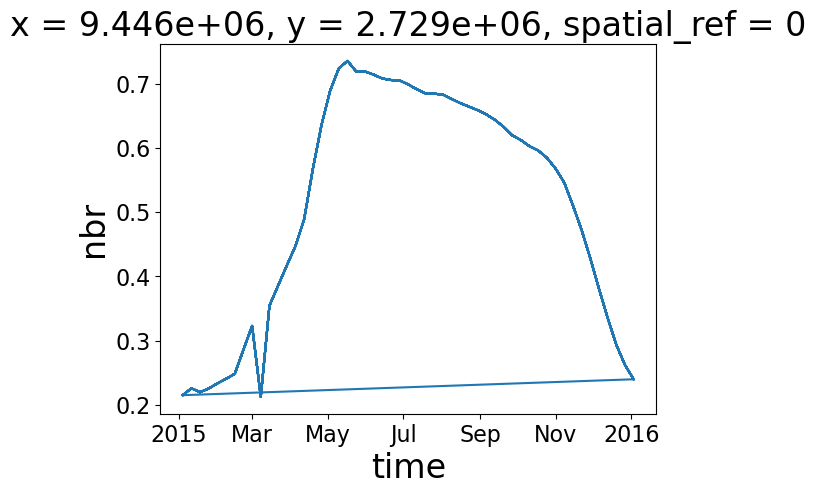

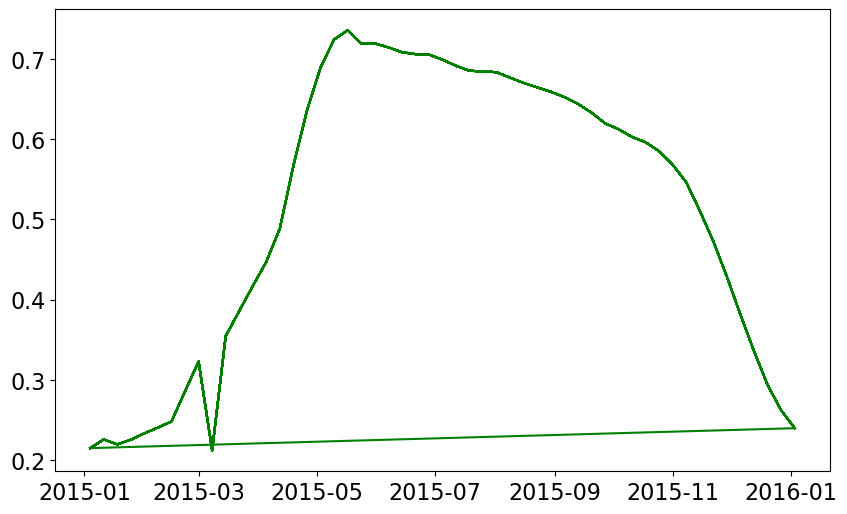

In [38]:
combined_stat['nbr'].plot()
plt.figure(figsize=(10, 6))


# Plot the original, smoothed, and difference data
plt.plot(combined_stat['time'], combined_stat['nbr'], color='green')

In [28]:
def calculate_difference(dataset, statistic='mean'):
    """
    Calculate the original NDVI time series, smoothed statistics, and their difference.

    Parameters:
        dataset (xarray.Dataset): The dataset containing NDVI values.
        x_idx (int): The x-coordinate index of the pixel.
        y_idx (int): The y-coordinate index of the pixel.
        statistic (str): The statistic to calculate for the "Perfect Season" ('mean', 'max', or 'min').
        window_size (int): The size of the rolling window for smoothing.

    Returns:
        original_weekly (xarray.DataArray): The original NDVI time series resampled weekly.
        smoothed_stat (xarray.DataArray): The smoothed NDVI statistic time series.
        difference (xarray.DataArray): The difference between the original and smoothed NDVI.
    """
    import xarray as xr
    import pandas as pd
    
    # Select the pixel at the specified coordinates
    ndvi_series = dataset
    
    # Resample the NDVI to weekly values
    original_weekly = ndvi_series.resample(time='W').mean()
    
    # Extract time information
    time = pd.to_datetime(ndvi_series['time'].values)
    start_year = time.min().year
    end_year = time.max().year
    
    # Add day of year (doy) as a coordinate
    ndvi_series.coords['doy'] = ('time', time.day_of_year)
    
    # Calculate the weekly statistic
    if statistic == 'mean':
        weekly_stat = ndvi_series.groupby('doy').mean(dim='time')
    elif statistic == 'max':
        weekly_stat = ndvi_series.groupby('doy').max(dim='time')
    elif statistic == 'min':
        weekly_stat = ndvi_series.groupby('doy').min(dim='time')
    else:
        raise ValueError("Statistic must be 'mean', 'max', or 'min'")
    
    # # Add timestamps to the statistic
    weekly_stat['time'] = ('doy', time)
    weekly_stat = weekly_stat.resample(time='W').mean()

    # # Define the number of weeks per year
    # #num_weeks_per_year = len(weekly_stat['time'])
    
    # # Create an empty list to hold the resampled statistics for each year
    # all_years_stat = []
    
    # # Iterate over all years in the dataset
    # for year in range(start_year, end_year + 1):
    #     date_range = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq='W')
        
    #     # Repeat the statistic values for each week
    #     #weekly_values_repeated = weekly_stat.isel(time=slice(0, num_weeks_per_year))
        
    #     # Create a new dataset with the desired time values
    #     new_time_dataset = xr.Dataset(
    #         data_vars={
    #             'time': ('time', date_range)
    #         }
    #     )
        
    #     # Convert the 'time' data of weekly_values_repeated to match the data type of new_time_dataset
    #     #weekly_values_repeated['time'] = new_time_dataset['time']
        
    #     # Use combine_first to concatenate the datasets while ignoring NaN values
    #     yearly_dataset = weekly_values_repeated.combine_first(new_time_dataset)
        
    #     # Append the yearly dataset to the list
    #     all_years_stat.append(yearly_dataset)
    

        # Generate a full time series for the "perfect season"
    all_years_stat = []
    for year in range(start_year, end_year + 1):
        # Create a date range for the full year (weekly frequency)
        date_range = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq='W')
        
        # Repeat the weekly statistics for each day of the year, matching the current year's time range
        yearly_stat = weekly_stat.reindex({'doy': range(1, 367)}, method='nearest')  # Ensure all 366 days are covered
        yearly_stat = yearly_stat.assign_coords(time=date_range[:len(yearly_stat['doy'])])
        yearly_stat.drop_vars('doy')
        all_years_stat.append(yearly_stat)
        
    # Combine all years' statistics into one dataset
    combined_stat = xr.concat(all_years_stat, dim='time')
    
    # Remove duplicate time values if any
    smoothed_stat = combined_stat.isel(time=~combined_stat['time'].to_series().duplicated())
    
    # Calculate the difference between the original and smoothed statistics
    difference = original_weekly - smoothed_stat
    
    return original_weekly, smoothed_stat, difference


In [24]:
# Example: Selecting a 5x5 pixel subset
subset = dataset.isel(x=slice(10, 15), y=slice(20, 25))
subset

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 433, x: 5, y: 5)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2015-03-19 2015-03-26 ... 2024-08-01
  * x            (x) float32 20B 9.446e+06 9.447e+06 ... 9.447e+06 9.447e+06
  * y            (y) float32 20B 2.729e+06 2.729e+06 ... 2.729e+06 2.729e+06
    spatial_ref  int64 8B 0
Data variables: (12/28)
    B06          (time, y, x) float32 43kB ...
    B03          (time, y, x) float32 43kB ...
    kndrs        (time, y, x) float32 43kB ...
    B8A          (time, y, x) float32 43kB ...
    vh           (time, y, x) float32 43kB ...
    tcb          (time, y, x) float32 43kB ...
    ...           ...
    B09          (time, y, x) float32 43kB ...
    tcw          (time, y, x) float32 43kB ...
    ndmi         (time, y, x) float32 43kB ...
    B01          (time, y, x) float32 43kB ...
    kdrs         (time, y, x) float32 43kB ...
    ndrs         (time, y, x) float32 43kB ...

In [27]:
original, season, difference = calculate_difference(dataset=ndvi_series, statistic='max')

ValueError: conflicting sizes for dimension 'doy': length 433 on 'time' and length 319 on {'doy': 'B06'}

ValueError: x and y can be no greater than 2D, but have shapes (395,) and (395, 512, 512)

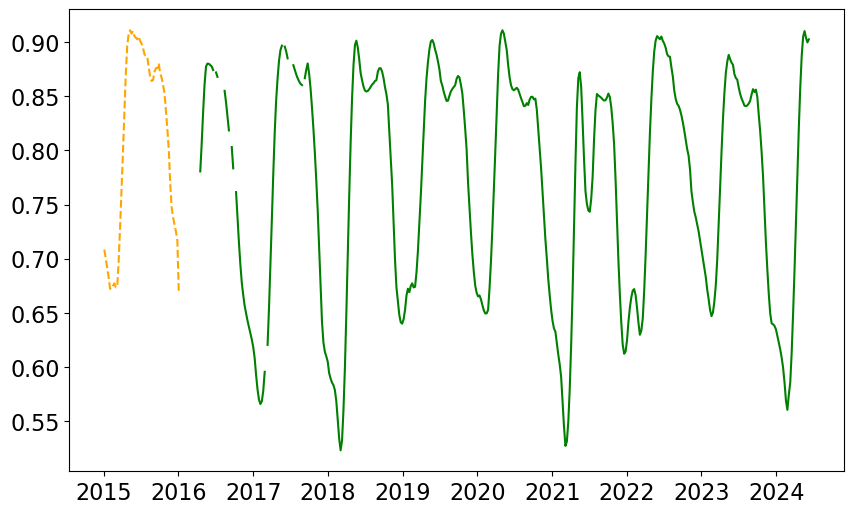

In [ ]:
# Step 8: Plot the combined statistics
plt.figure(figsize=(10, 6))
plt.plot(original_weekly['time'], original_weekly['ndvi'], label=f"Original NDVI", color='green')
plt.plot(smoothed_stat['time'], smoothed_stat['ndvi'], label=f"Smoothed Weekly {statistic.capitalize()} NDVI", linestyle='--', color='orange')
plt.plot(difference['time'], difference['ndvi'], label=f"Difference {statistic.capitalize()} NDVI", linestyle='-', color='blue')
plt.axhline(y=0, color='red', linestyle='-', linewidth=1)
#plt.plot(ndvi_difference, ndvi_difference, label=f"Difference {statistic.capitalize()} NDVI", linestyle='-', color='blue')
# Adding labels and title
plt.xlabel('Date')
plt.ylabel('NDVI/NDVI_Anom')
plt.title(f'Extended {statistic.capitalize()} NDVI Season for {start_year}-{end_year}')

# Show grid and make the plot tighter
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [18]:
def plot_statistics(original, smoothed, difference, x_idx, y_idx, variable='ndvi', statistic='max', start_year=None, end_year=None):
    """
    Plot the original, smoothed, and difference NDVI statistics for a specific pixel and variable.

    Parameters:
        original (xarray.DataArray): The original NDVI time series resampled weekly.
        smoothed (xarray.DataArray): The smoothed NDVI statistic time series.
        difference (xarray.DataArray): The difference between the original and smoothed NDVI.
        x_idx (int): The x-coordinate index of the pixel.
        y_idx (int): The y-coordinate index of the pixel.
        variable (str): The variable name to plot (default is 'ndvi').
        statistic (str): The statistic type ('mean', 'max', or 'min') for labeling the plot.
        start_year (int): The start year of the dataset (optional, for labeling).
        end_year (int): The end year of the dataset (optional, for labeling).

    Returns:
        None
    """
    import matplotlib.pyplot as plt

    # Create the plot
    plt.figure(figsize=(10, 6))
    original = original.isel(x=x_idx, y=y_idx)
    smoothed = smoothed.isel(x=x_idx, y=y_idx)
    difference = difference.isel(x=x_idx, y=y_idx)

    
    # Plot the original, smoothed, and difference data
    plt.plot(original['time'], original[variable], label=f"Original {variable.upper()}", color='green')
    plt.plot(smoothed['time'], smoothed[variable], label=f"Smoothed Weekly {statistic.capitalize()} {variable.upper()}", linestyle='--', color='orange')
    plt.plot(difference['time'], difference[variable], label=f"Difference {statistic.capitalize()} {variable.upper()}", linestyle='-', color='blue')
    
    # Add a horizontal line at y=0
    plt.axhline(y=0, color='red', linestyle='-', linewidth=1, label='y = 0')
    
    # Adding labels and title
    plt.xlabel('Date')
    plt.ylabel(variable.upper())
    title = f"Extended {statistic.capitalize()} {variable.upper()} Season"
    if start_year and end_year:
        title += f" for {start_year}-{end_year}"
    plt.title(title)
    
    # Show grid and make the plot tighter
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()


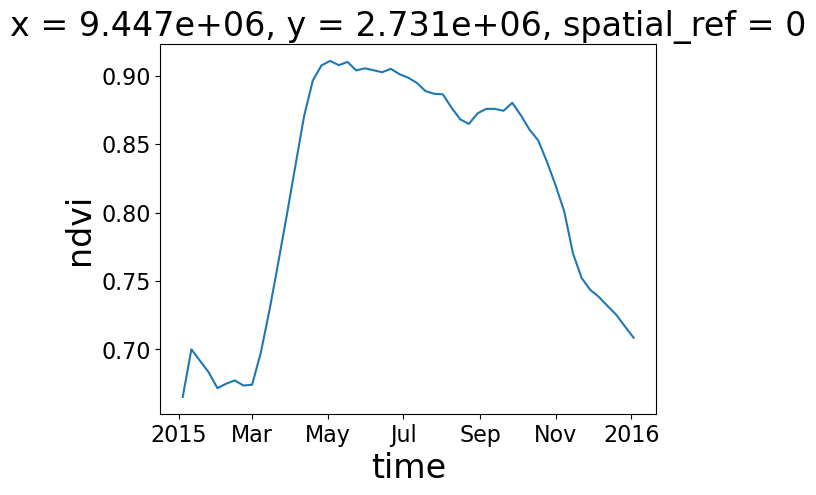

In [58]:
import pandas as pd
import matplotlib.pyplot as plt


# Now resample to weekly data (W stands for weekly frequency)
weekly_ndvi_max = ndvi_max_tem.resample(time='W').max()
weekly_ndvi_max['ndvi'].plot()


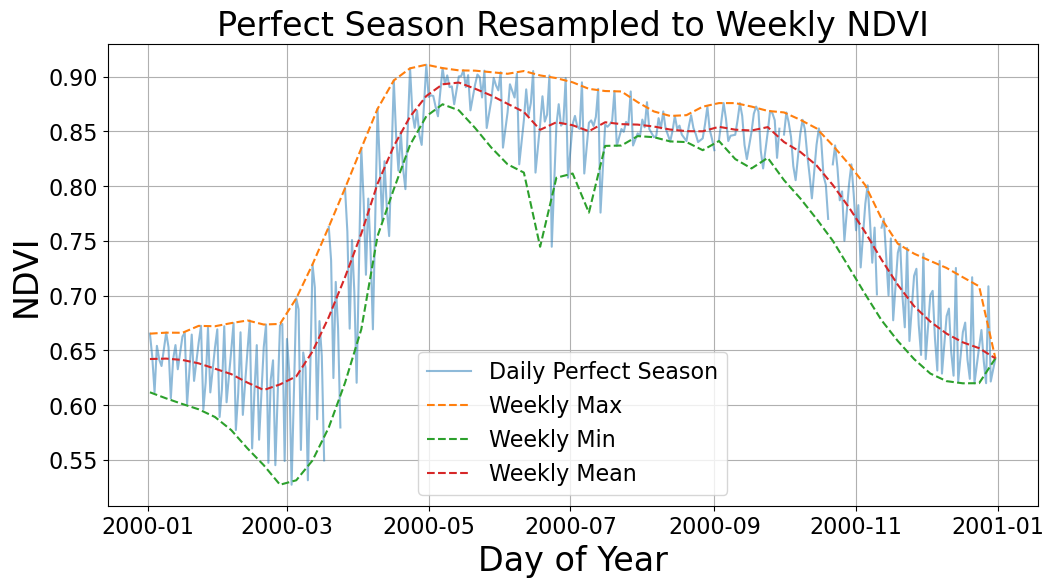

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Assuming 'dataset' is already loaded, and 'ndvi' has time, x, y coordinates.
# Step 1: Select the pixel and create the daily "Perfect Season"
ndvi_series = dataset['ndvi'].isel(x=20, y=200)

# Assuming `ndvi_series` already exists
time = pd.to_datetime(ndvi_series['time'].values)

# Create "Perfect Season" (mean across time grouped by day_of_year)
ndvi_series.coords['day_of_year'] = ('time', time.day_of_year)
perfect_season = ndvi_series.groupby('day_of_year').mean(dim='time')

# Fix: Match dummy dates only to the days available in `perfect_season`
unique_days = perfect_season['day_of_year'].values  # Get unique day_of_year values (e.g., 1-365 but may be incomplete)
dummy_dates = pd.date_range(start="2000-01-01", end="2000-12-31")  # Full year
dummy_dates = dummy_dates[dummy_dates.day_of_year.isin(unique_days)]  # Match only available days

# Assign the adjusted day_of_year coordinate
perfect_season['day_of_year'] = dummy_dates.day_of_year
perfect_season_time = perfect_season.assign_coords(day_of_year=dummy_dates)

# Resample to weekly and calculate max, min, and mean
perfect_season_weekly = perfect_season_time.resample(day_of_year="7D")
perfect_season_weekly_max = perfect_season_weekly.max()
perfect_season_weekly_min = perfect_season_weekly.min()
perfect_season_weekly_mean = perfect_season_weekly.mean()


# Plot the results
plt.figure(figsize=(12, 6))

# Original daily perfect season
plt.plot(perfect_season_time['day_of_year'], perfect_season_time, label="Daily Perfect Season", alpha=0.5)

# Weekly statistics
plt.plot(perfect_season_weekly_max['day_of_year'], perfect_season_weekly_max, label="Weekly Max", linestyle="--")
plt.plot(perfect_season_weekly_min['day_of_year'], perfect_season_weekly_min, label="Weekly Min", linestyle="--")
plt.plot(perfect_season_weekly_mean['day_of_year'], perfect_season_weekly_mean, label="Weekly Mean", linestyle="--")

# Add labels and legend
plt.xlabel("Day of Year")
plt.ylabel("NDVI")
plt.title("Perfect Season Resampled to Weekly NDVI")
plt.legend()
plt.grid()
plt.show()
